# 📊 Análise Exploratória de Dados (EDA)

### 1. Introdução

Este notebook tem como objetivo realizar a análise exploratória de dados (Exploratory Data Analysis — EDA) do dataset utilizado no projeto de classificação de notícias com Machine Learning.

A análise exploratória é uma etapa fundamental no desenvolvimento de modelos de aprendizado de máquina, pois permite compreender melhor:

* a estrutura dos dados;
* a distribuição das categorias;
* possíveis desbalanceamentos;
* qualidade textual;
* presença de valores nulos ou duplicados;
* e características relevantes para o pré-processamento e modelagem.

O dataset utilizado contém notícias categorizadas, compostas pelos seguintes campos principais:

* `headline`
* `short_description`
* `category`

Ao longo deste notebook serão realizadas análises estatísticas e visuais para auxiliar na tomada de decisão das próximas etapas do projeto, incluindo:

* estratégia de entrada textual;
* tratamento de classes;
* engenharia de atributos;
* e definição do pipeline de treinamento.

---

#### Objetivos da análise

* Compreender a distribuição das categorias
* Investigar possíveis desbalanceamentos
* Analisar o tamanho dos textos
* Avaliar a qualidade textual do dataset
* Definir a melhor estratégia de representação textual
* Identificar possíveis problemas nos dados

---

#### Estrutura do notebook

1. Introdução
2. Carregamento do dataset
3. Informações gerais
4. Verificação de valores nulos
5. Verificação de duplicados
6. Distribuição das categorias
7. Análise do tamanho dos textos
8. Balanceamento das classes
9. Estratégia textual
10. Conclusões do EDA


### 2. Carregamento do dataset

In [5]:
# ==========================================
# Bibliotecas
# ==========================================

import json
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Configurações
# ==========================================

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")

# ==========================================
# Carregamento do dataset
# ==========================================

DATASET_PATH = "../data/raw/News_Category_Dataset_v3.json"

df = pd.read_json(DATASET_PATH, lines=True)

# ==========================================
# Visualização inicial
# ==========================================

print(f"Quantidade de registros: {len(df)}")
print(f"Quantidade de colunas: {df.shape[1]}")

display(df.head())


Quantidade de registros: 209527
Quantidade de colunas: 6


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-uptake-us_n_632d719ee4b087fae6feaac9,Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters,U.S. NEWS,Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new b...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlines-passenger-banned-flight-attendant-punch-justice-department_n_632e25...,"American Airlines Flyer Charged, Banned For Life After Punching Flight Attendant On Video",U.S. NEWS,"He was subdued by passengers and crew when he fled to the back of the aircraft after the confrontation, according to...",Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets-cats-dogs-september-17-23_n_632de332e4b0695c1d81dc02,23 Of The Funniest Tweets About Cats And Dogs This Week (Sept. 17-23),COMEDY,"""Until you have a dog you don't understand what could be eaten.""",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parenting-tweets_l_632d7d15e4b0d12b5403e479,The Funniest Tweets From Parents This Week (Sept. 17-23),PARENTING,"""Accidentally put grown-up toothpaste on my toddler’s toothbrush and he screamed like I was cleaning his teeth with ...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-loses-discrimination-lawsuit-franklin-templeton_n_632c6463e4b09d8701bd227e,Woman Who Called Cops On Black Bird-Watcher Loses Lawsuit Against Ex-Employer,U.S. NEWS,Amy Cooper accused investment firm Franklin Templeton of unfairly firing her and branding her a racist after video o...,Nina Golgowski,2022-09-22


### 3. Informações gerais


In [6]:
# ==========================================
# 3. Informações gerais
# ==========================================

print("Dimensões do dataset:")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

print("\n" + "=" * 50)

print("Colunas disponíveis:")
display(df.columns)

print("\n" + "=" * 50)

print("Tipos de dados:")
display(df.dtypes)

print("\n" + "=" * 50)

print("Informações gerais do dataset:")
df.info()

print("\n" + "=" * 50)

print("Estatísticas descritivas:")
display(df.describe(include="all"))

print("\n" + "=" * 50)

print("Amostra aleatória do dataset:")
display(df.sample(5, random_state=42))

Dimensões do dataset:
Linhas: 209527
Colunas: 6

Colunas disponíveis:


Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='str')


Tipos de dados:


link                            str
headline                        str
category                        str
short_description               str
authors                         str
date                 datetime64[us]
dtype: object


Informações gerais do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  str           
 1   headline           209527 non-null  str           
 2   category           209527 non-null  str           
 3   short_description  209527 non-null  str           
 4   authors            209527 non-null  str           
 5   date               209527 non-null  datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 9.6 MB

Estatísticas descritivas:


,link,headline,category,short_description,authors,date
count,209527,209527,209527,209527,209527,209527
unique,209486,207996,42,187022,29169,NaN
top,https://www.huffingtonpost.comhttp://www.politico.com/story/2016/06/hardly-anybody-wants-to-speak-at-trumps-conventi...,Sunday Roundup,POLITICS,,,NaN
freq,2,90,35602,19712,37418,NaN
mean,NaN,NaN,NaN,NaN,NaN,2015-04-30 00:44:14.344308
min,NaN,NaN,NaN,NaN,NaN,2012-01-28 00:00:00
25%,NaN,NaN,NaN,NaN,NaN,2013-08-10 00:00:00
50%,NaN,NaN,NaN,NaN,NaN,2015-03-16 00:00:00
75%,NaN,NaN,NaN,NaN,NaN,2016-11-01 00:00:00
max,NaN,NaN,NaN,NaN,NaN,2022-09-23 00:00:00



Amostra aleatória do dataset:


,link,headline,category,short_description,authors,date
128310,https://www.huffingtonpost.com/entry/what-if-we-were-all-famil_b_5510958.html,What If We Were All Family Generation Changers?,IMPACT,"What if, in doing so, we won't just create new opportunities for ourselves, we'll also uncover ways to create new op...","Matt Murrie, ContributorEdupreneur, Cofounder/Chief Curiosity Curator of What If...?",2014-06-20
139983,https://www.huffingtonpost.comhttp://www.washingtonpost.com/business/economy/aol-chief-ignites-firestorm-over-401k-c...,Firestorm At AOL Over Employee Benefit Cuts,BUSINESS,"It should have been a glorious week for AOL chief executive Tim Armstrong. His company’s quarterly earnings, announc...",,2014-02-08
42339,https://www.huffingtonpost.com/entry/time-runs-out-at-main-dakota-access-pipeline-protest-camp_us_58acc6a9e4b04a0b27...,Dakota Access Protesters Arrested As Deadline Passes To Depart Camp,POLITICS,A few protesters who refused to leave remained at the site Thursday.,"Michael McLaughlin & Josh Morgan, The Huffington Post",2017-02-22
131494,https://www.huffingtonpost.com/entry/one-glimpse-of-these-baby_n_5319015.html,One Glimpse Of These Baby Kit Foxes And You'll Be Hooked,GREEN,,,2014-05-14
163649,https://www.huffingtonpost.com/entry/mens-sweat-pheromone-cooperation_us_5baeb6f0e4b014374e2e5ae6,"Mens' Sweat Pheromone, Androstadienone, Influences Cooperation In Other Men",SCIENCE,"Scientists didn't know if humans played that game as well. But in the last 30 years, they've identified both male an...",Melissa Cronin,2013-06-02


### 4. Verificação de valores nulos


Valores nulos por coluna:


,Valores nulos,Percentual (%)
link,0,0.0
headline,0,0.0
category,0,0.0
short_description,0,0.0
authors,0,0.0
date,0,0.0


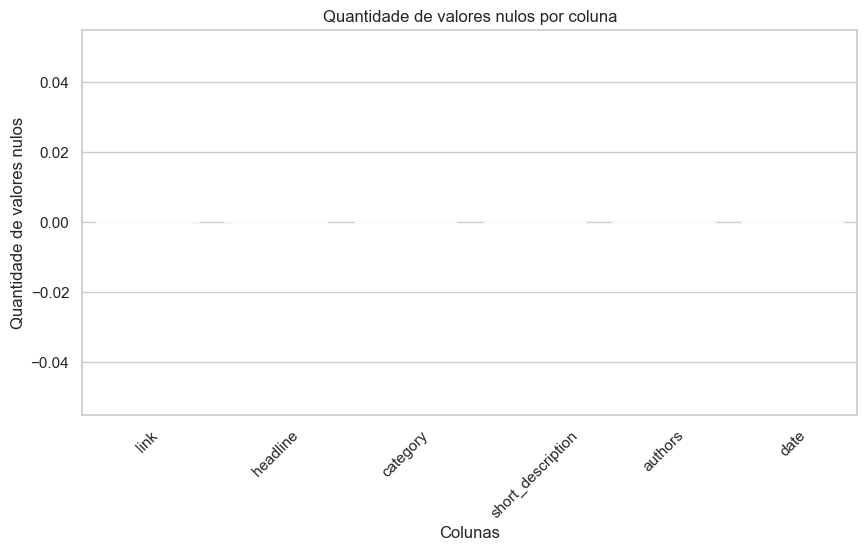

In [7]:
# ==========================================
# 4. Verificação de valores nulos
# ==========================================

null_values = df.isnull().sum()

null_percentage = (
    (df.isnull().sum() / len(df)) * 100
).round(2)

null_analysis = pd.DataFrame({
    "Valores nulos": null_values,
    "Percentual (%)": null_percentage
})

print("Valores nulos por coluna:")
display(null_analysis)

# ==========================================
# Visualização gráfica
# ==========================================

plt.figure(figsize=(10, 5))

sns.barplot(
    x=null_analysis.index,
    y=null_analysis["Valores nulos"]
)

plt.title("Quantidade de valores nulos por coluna")
plt.xlabel("Colunas")
plt.ylabel("Quantidade de valores nulos")

plt.xticks(rotation=45)

plt.show()

### 5. Verificação de duplicados


In [8]:
# ==========================================
# 5. Verificação de duplicados
# ==========================================

# Verificação de linhas totalmente duplicadas

duplicated_rows = df.duplicated().sum()

print(f"Quantidade de linhas duplicadas: {duplicated_rows}")

# ==========================================
# Verificação específica do texto
# ==========================================

duplicated_headlines = df["headline"].duplicated().sum()

print(f"\nHeadlines duplicadas: {duplicated_headlines}")

# ==========================================
# Concatenando texto para análise
# ==========================================

df["full_text"] = (
    df["headline"].fillna("") + " " +
    df["short_description"].fillna("")
)

duplicated_full_text = df["full_text"].duplicated().sum()

print(f"\nTextos completos duplicados: {duplicated_full_text}")

# ==========================================
# Exemplo de duplicados
# ==========================================

print("\nExemplos de textos duplicados:")

display(
    df[df["full_text"].duplicated(keep=False)]
    [["category", "headline", "short_description"]]
    .head(10)
)

Quantidade de linhas duplicadas: 13

Headlines duplicadas: 1531

Textos completos duplicados: 489

Exemplos de textos duplicados:


,category,headline,short_description
5225,WORLD NEWS,Netanyahu Holds Solid Lead In Israeli Elections,Early exit polls show Prime Minister Benjamin Netanyahu holds a solid edge over his main rival in Israel’s third ele...
5226,WORLD NEWS,Netanyahu Holds Solid Lead In Israeli Elections,Early exit polls show Prime Minister Benjamin Netanyahu holds a solid edge over his main rival in Israel’s third ele...
17640,PARENTS,The Funniest Tweets From Parents This Week,"Kids may say the darndest things, but parents tweet about them in the funniest ways. So each week, we round up the m..."
18164,PARENTS,The Funniest Tweets From Parents This Week,"Kids may say the darndest things, but parents tweet about them in the funniest ways. So each week, we round up the m..."
18974,ENTERTAINMENT,"With This 'Shape Of Water' Clip, You'll Fall For Octavia Spencer In 60 Seconds",Spencer and Sally Hawkins play 1960s janitors in Guillermo del Toro's wonderful new movie.
19009,ENTERTAINMENT,"With This 'Shape Of Water' Clip, You'll Fall For Octavia Spencer In 60 Seconds",Spencer and Sally Hawkins play 1960s janitors in Guillermo del Toro's wonderful new movie.
19037,MEDIA,"From Layoffs To Sexual Assault Allegations, It's Been A Hard Week In Media","BuzzFeed, ESPN, ""Today"" and more hit new breaking points."
19045,ARTS & CULTURE,This New York Activist Wants To Replace A Statue Of Columbus With Toussaint L’Ouverture,Glenn Cantave believes white supremacy in 2017 stems back to 1492. And he's letting NYC's mayoral commission know.
19058,STYLE,The Worst Beauty Trends Of 2017,"Bye-bye, glitter butts."
19064,POLITICS,"Abortion Isn’t Main Reason More Republicans Still Won’t Back Doug Jones, New Poll Finds",Would the Democrats’ Alabama Senate candidate do better if he were anti-abortion? Maybe not.


###  6. Distribuição das categorias


Quantidade de categorias:
42

Distribuição das categorias:


category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

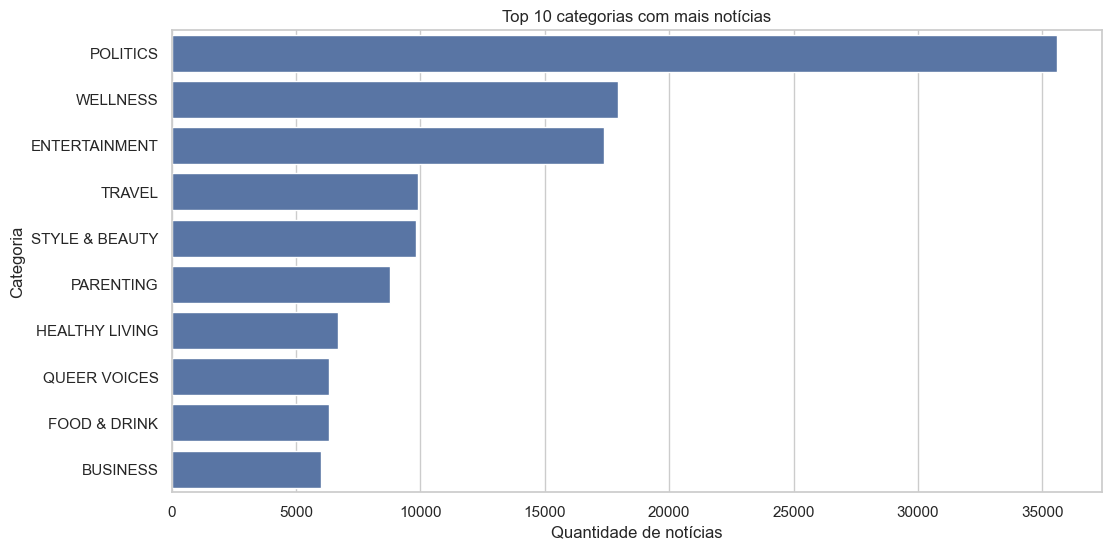

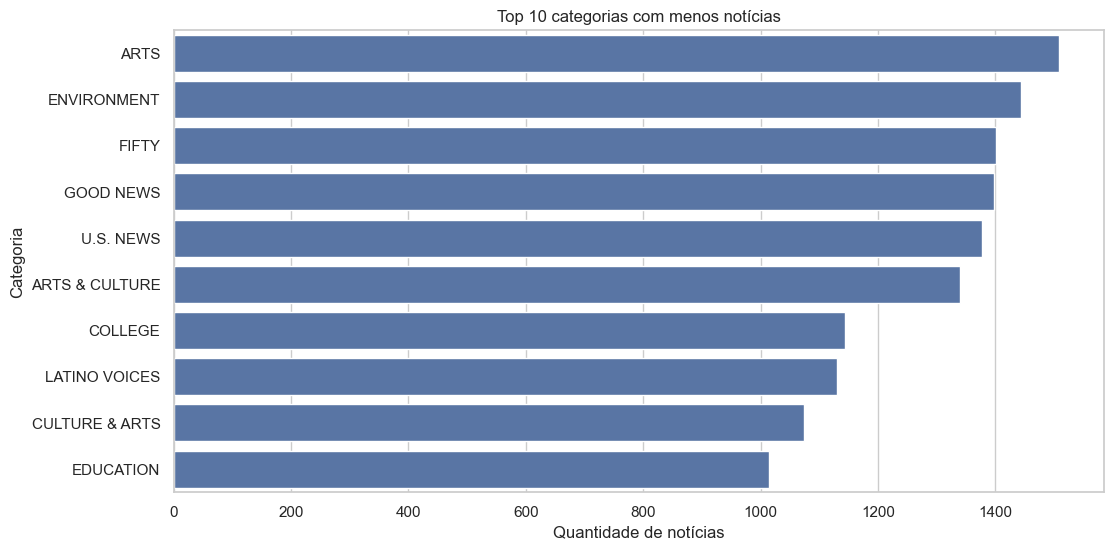

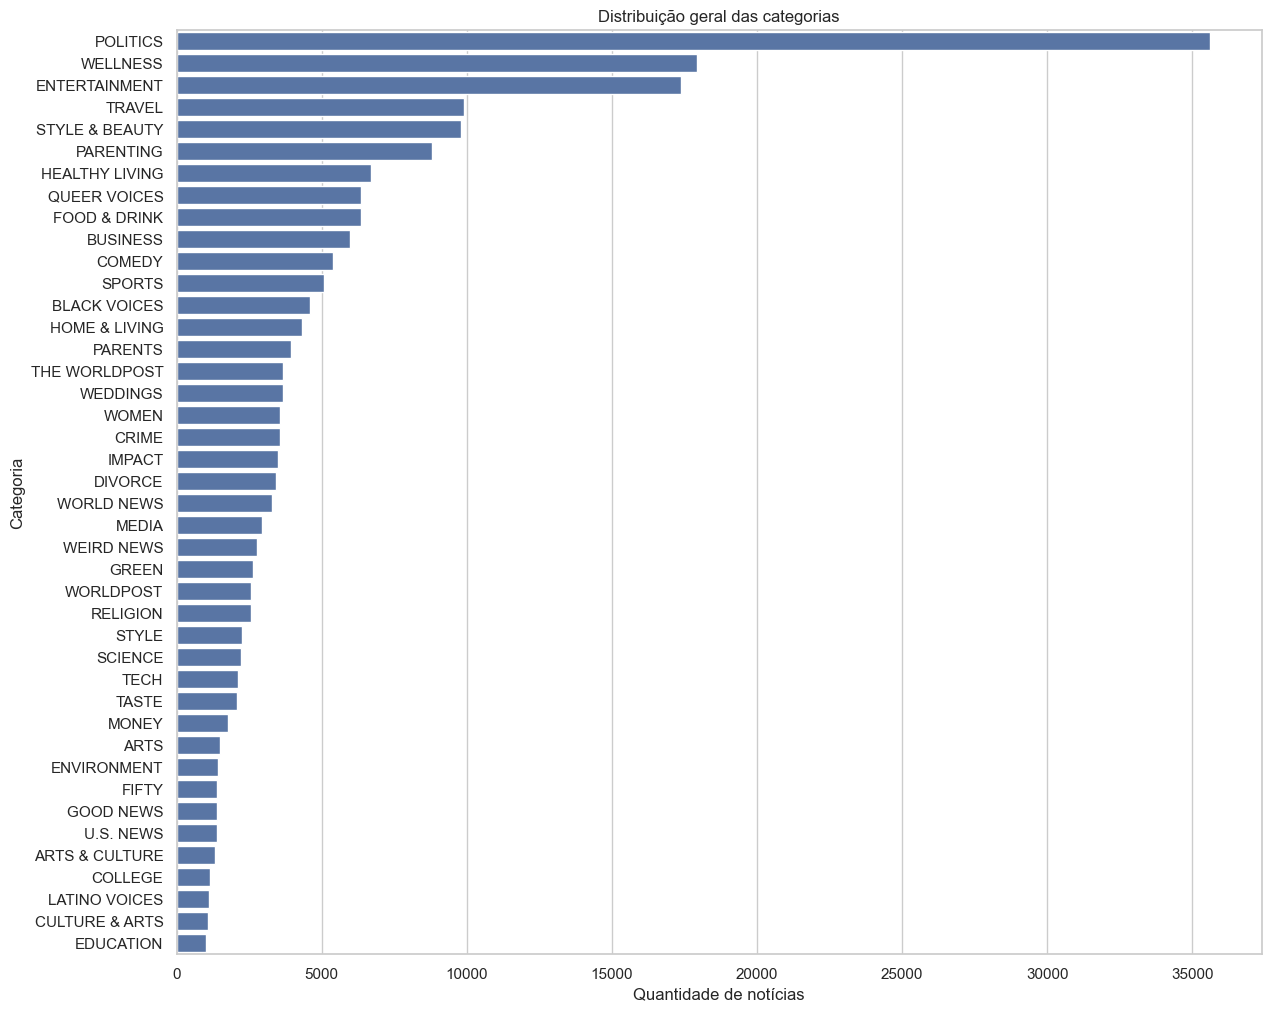

In [9]:
# ==========================================
# 6. Distribuição das categorias
# ==========================================

category_counts = (
    df["category"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Quantidade de categorias:")
print(df["category"].nunique())

print("\nDistribuição das categorias:")
display(category_counts)

# ==========================================
# Top 10 maiores categorias
# ==========================================

top_10 = category_counts.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10.values,
    y=top_10.index
)

plt.title("Top 10 categorias com mais notícias")
plt.xlabel("Quantidade de notícias")
plt.ylabel("Categoria")

plt.show()

# ==========================================
# Top 10 menores categorias
# ==========================================

bottom_10 = category_counts.tail(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=bottom_10.values,
    y=bottom_10.index
)

plt.title("Top 10 categorias com menos notícias")
plt.xlabel("Quantidade de notícias")
plt.ylabel("Categoria")

plt.show()

# ==========================================
# Distribuição geral
# ==========================================

plt.figure(figsize=(14, 12))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Distribuição geral das categorias")
plt.xlabel("Quantidade de notícias")
plt.ylabel("Categoria")

plt.show()

###  7. Análise do tamanho dos textos


,Headline,Short Description,Texto Completo
count,209527.000000,209527.000000,209527.000000
mean,9.600744,19.669026,29.269770
std,3.068507,14.152783,13.803927
min,0.000000,0.000000,0.000000
25%,8.000000,10.000000,20.000000
50%,10.000000,19.000000,28.000000
75%,12.000000,24.000000,35.000000
max,44.000000,243.000000,245.000000


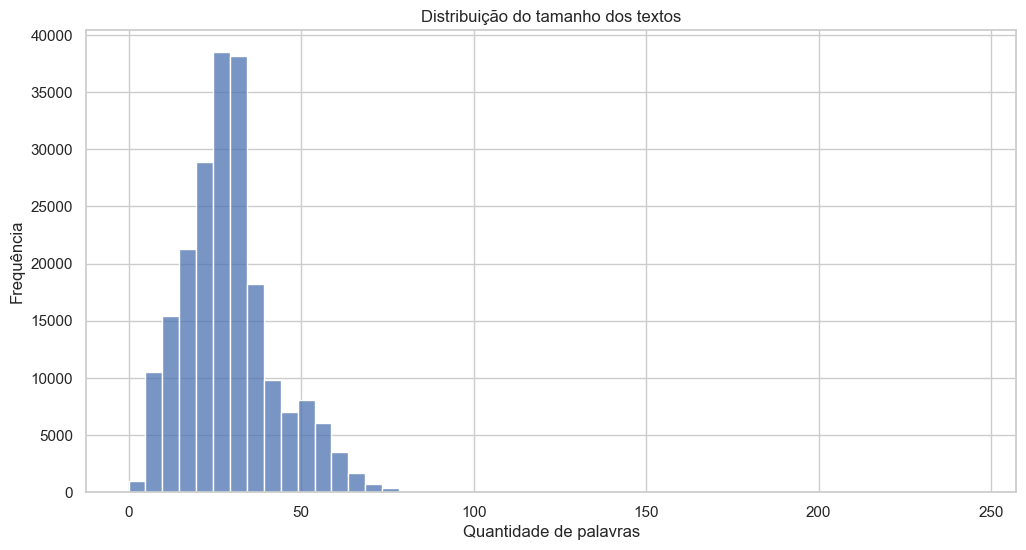

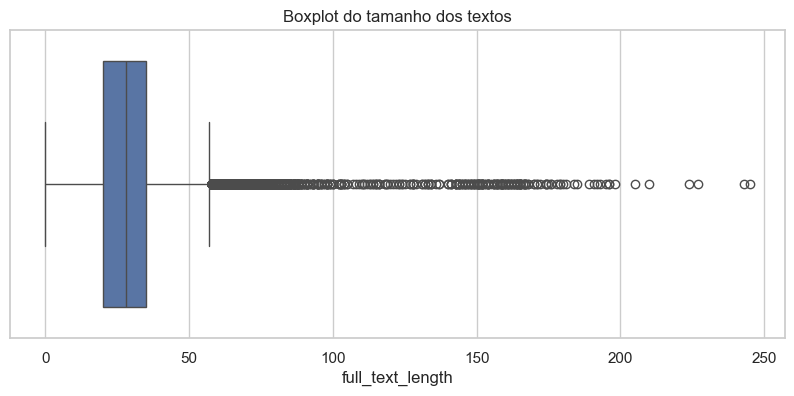

In [10]:
# ==========================================
# 7. Análise do tamanho dos textos
# ==========================================

# ==========================================
# Quantidade de palavras
# ==========================================

df["headline_length"] = (
    df["headline"]
    .fillna("")
    .apply(lambda x: len(x.split()))
)

df["description_length"] = (
    df["short_description"]
    .fillna("")
    .apply(lambda x: len(x.split()))
)

df["full_text_length"] = (
    df["full_text"]
    .apply(lambda x: len(x.split()))
)

# ==========================================
# Estatísticas
# ==========================================

text_stats = pd.DataFrame({
    "Headline": df["headline_length"].describe(),
    "Short Description": df["description_length"].describe(),
    "Texto Completo": df["full_text_length"].describe()
})

display(text_stats)

# ==========================================
# Histograma
# ==========================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["full_text_length"],
    bins=50
)

plt.title("Distribuição do tamanho dos textos")
plt.xlabel("Quantidade de palavras")
plt.ylabel("Frequência")

plt.show()

# ==========================================
# Boxplot
# ==========================================

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["full_text_length"]
)

plt.title("Boxplot do tamanho dos textos")

plt.show()


###  8. Balanceamento das classes


,Quantidade,Percentual (%)
category,,
POLITICS,35602,16.99
WELLNESS,17945,8.56
ENTERTAINMENT,17362,8.29
TRAVEL,9900,4.72
STYLE & BEAUTY,9814,4.68
PARENTING,8791,4.20
HEALTHY LIVING,6694,3.19
QUEER VOICES,6347,3.03
FOOD & DRINK,6340,3.03


Categorias com menos de 1% do dataset:


,Quantidade,Percentual (%)
category,,
MONEY,1756,0.84
ARTS,1509,0.72
ENVIRONMENT,1444,0.69
FIFTY,1401,0.67
GOOD NEWS,1398,0.67
U.S. NEWS,1377,0.66
ARTS & CULTURE,1339,0.64
COLLEGE,1144,0.55
LATINO VOICES,1130,0.54


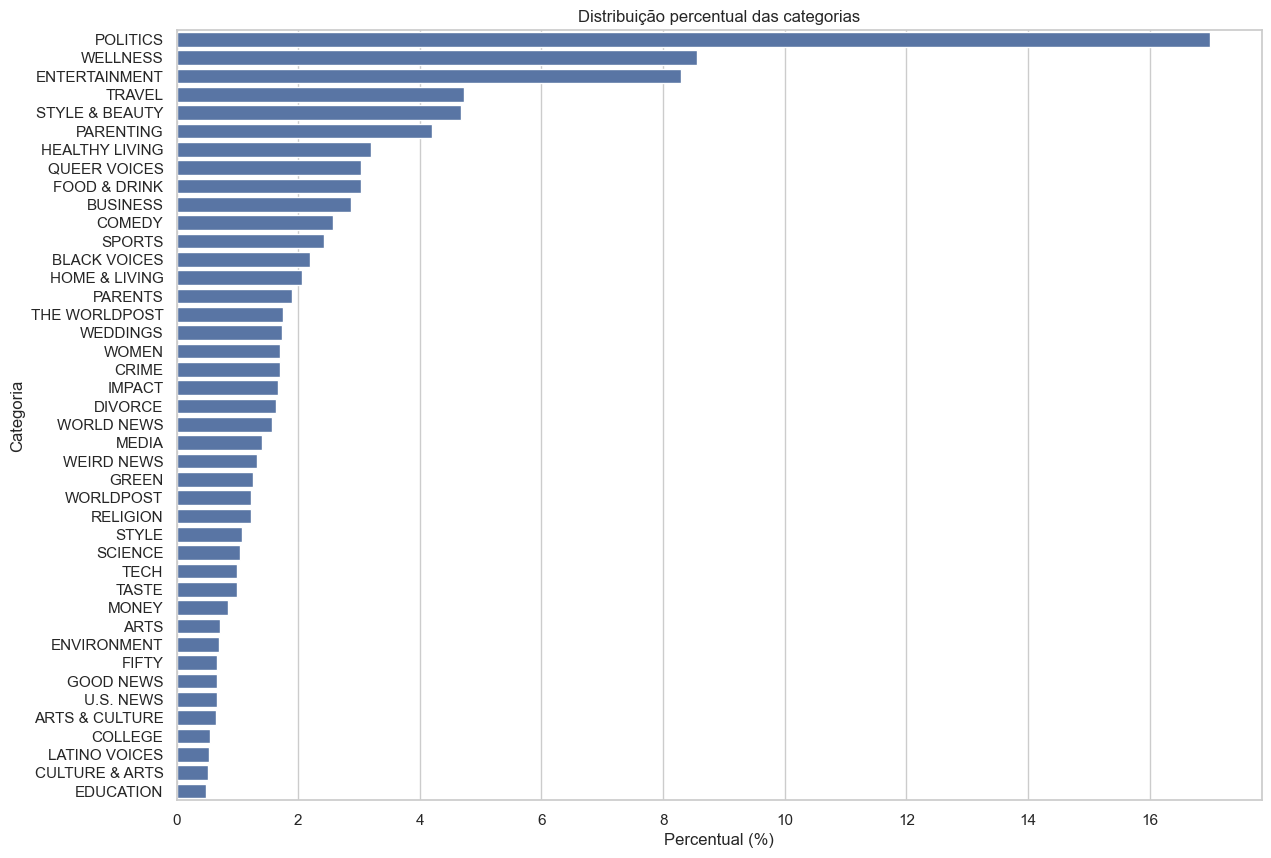

Maior classe: 35602
Menor classe: 1014
Razão de desbalanceamento: 35.11


In [11]:
# ==========================================
# 8. Balanceamento das classes
# ==========================================

category_distribution = (
    df["category"]
    .value_counts(normalize=True)
    * 100
).round(2)

balance_df = pd.DataFrame({
    "Quantidade": df["category"].value_counts(),
    "Percentual (%)": category_distribution
})

display(balance_df)

# ==========================================
# Categorias com menos de 1%
# ==========================================

low_representation = balance_df[
    balance_df["Percentual (%)"] < 1
]

print("Categorias com menos de 1% do dataset:")

display(low_representation)

# ==========================================
# Visualização do desbalanceamento
# ==========================================

plt.figure(figsize=(14, 10))

sns.barplot(
    x=balance_df["Percentual (%)"],
    y=balance_df.index
)

plt.title("Distribuição percentual das categorias")
plt.xlabel("Percentual (%)")
plt.ylabel("Categoria")

plt.show()

# ==========================================
# Informações gerais do balanceamento
# ==========================================

largest_class = balance_df["Quantidade"].max()
smallest_class = balance_df["Quantidade"].min()

imbalance_ratio = round(
    largest_class / smallest_class,
    2
)

print(f"Maior classe: {largest_class}")
print(f"Menor classe: {smallest_class}")
print(f"Razão de desbalanceamento: {imbalance_ratio}")


###  9. Estratégia textual (headline vs concatenação)


HEADLINE
Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters

SHORT DESCRIPTION
Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.

TEXTO CONCATENADO
Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.

COMPARAÇÃO DE TAMANHO
Média de palavras (headline): 9.60
Média de palavras (texto completo): 29.27


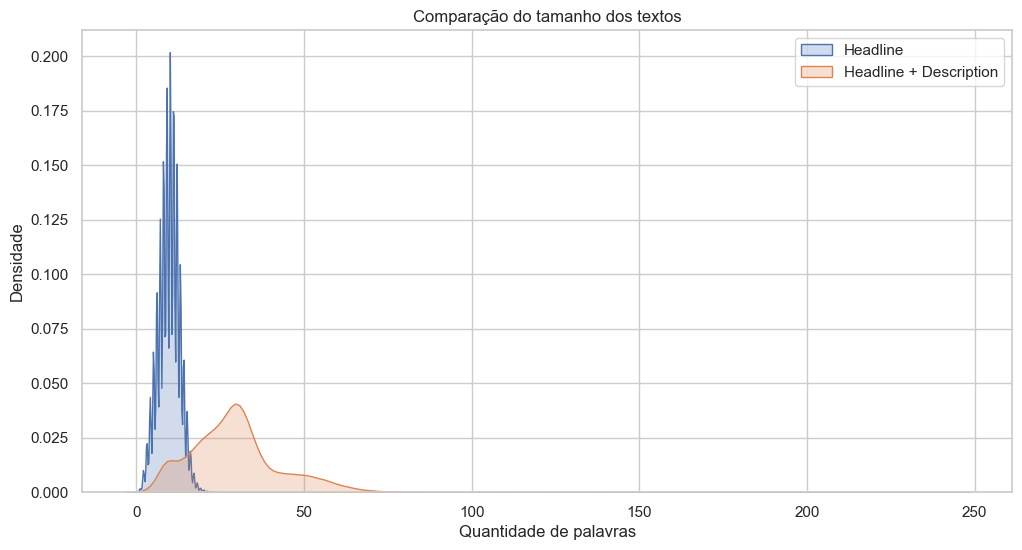


DECISÃO FINAL

A estratégia escolhida para o projeto será a utilização da
concatenação entre 'headline' e 'short_description'.

Motivos:
- headlines isoladas podem ser ambíguas;
- algumas manchetes possuem características sensacionalistas;
- o short_description adiciona contexto sem aumentar excessivamente
  o tamanho do texto;
- textos mais completos tendem a melhorar a representação semântica
  para modelos de classificação textual.



In [12]:
# ==========================================
# 9. Estratégia textual
# Headline vs Headline + Short Description
# ==========================================

# =====================================================
# Exemplo comparativo
# =====================================================

sample_index = 0

headline_example = df.loc[sample_index, "headline"]
description_example = df.loc[sample_index, "short_description"]

concatenated_example = (
    f"{headline_example} {description_example}"
)

print("=" * 80)
print("HEADLINE")
print("=" * 80)
print(headline_example)

print("\n" + "=" * 80)
print("SHORT DESCRIPTION")
print("=" * 80)
print(description_example)

print("\n" + "=" * 80)
print("TEXTO CONCATENADO")
print("=" * 80)
print(concatenated_example)

# =====================================================
# Criação da coluna textual final
# =====================================================

df["text"] = (
    df["headline"].fillna("") + " " +
    df["short_description"].fillna("")
)

# Removendo espaços extras
df["text"] = df["text"].str.strip()

# =====================================================
# Estatísticas comparativas
# =====================================================

headline_avg = df["headline_length"].mean()
full_text_avg = df["full_text_length"].mean()

print("\n" + "=" * 80)
print("COMPARAÇÃO DE TAMANHO")
print("=" * 80)

print(f"Média de palavras (headline): {headline_avg:.2f}")
print(f"Média de palavras (texto completo): {full_text_avg:.2f}")

# =====================================================
# Visualização da distribuição
# =====================================================

plt.figure(figsize=(12, 6))

sns.kdeplot(
    df["headline_length"],
    label="Headline",
    fill=True
)

sns.kdeplot(
    df["full_text_length"],
    label="Headline + Description",
    fill=True
)

plt.title("Comparação do tamanho dos textos")
plt.xlabel("Quantidade de palavras")
plt.ylabel("Densidade")

plt.legend()

plt.show()

# =====================================================
# Conclusão
# =====================================================

print("\n" + "=" * 80)
print("DECISÃO FINAL")
print("=" * 80)

print("""
A estratégia escolhida para o projeto será a utilização da
concatenação entre 'headline' e 'short_description'.

Motivos:
- headlines isoladas podem ser ambíguas;
- algumas manchetes possuem características sensacionalistas;
- o short_description adiciona contexto sem aumentar excessivamente
  o tamanho do texto;
- textos mais completos tendem a melhorar a representação semântica
  para modelos de classificação textual.
""")


###  10. Conclusões do EDA

A análise exploratória dos dados permitiu compreender a estrutura, a qualidade e os principais desafios do dataset utilizado no projeto de classificação de notícias com Machine Learning.

O dataset possui **209.527 registros** e **6 colunas**: `link`, `headline`, `category`, `short_description`, `authors` e `date`. As colunas principais para a tarefa de classificação textual são `headline`, `short_description` e `category`.

O conjunto de dados apresenta notícias publicadas entre **2012 e 2022**, com média temporal próxima ao ano de **2015**, indicando que o dataset possui uma cobertura ampla de diferentes períodos.

---

#### Estrutura geral dos dados

O dataset possui uma estrutura adequada para uma tarefa de classificação supervisionada, pois contém textos associados a categorias previamente definidas.

As colunas textuais `headline` e `short_description` estão disponíveis para todos os registros, sem valores nulos explícitos segundo a análise com `df.info()`. No entanto, a análise descritiva indicou que existem campos vazios, especialmente em `short_description` e `authors`, já que a descrição mais frequente aparece como uma string vazia.

Isso mostra que, apesar de não haver valores nulos formais, existem valores ausentes representados como texto vazio. Esse ponto deve ser considerado na etapa de pré-processamento.

---

#### Valores duplicados

A análise identificou:

- **13 linhas totalmente duplicadas**
- **1.531 headlines duplicadas**
- **489 textos completos duplicados**, considerando a concatenação entre `headline` e `short_description`

A quantidade de linhas totalmente duplicadas é pequena em relação ao tamanho total do dataset. No entanto, a presença de headlines e textos completos repetidos indica que pode haver notícias republicadas, textos similares ou registros redundantes.

Para a etapa de modelagem, é recomendável remover duplicatas completas e avaliar a remoção de textos completos duplicados, especialmente para evitar vazamento de informação entre treino e teste.

---

#### Distribuição das categorias

O dataset possui **42 categorias**, caracterizando um problema de classificação multiclasses.

A distribuição das categorias não é uniforme. A categoria mais frequente é `POLITICS`, com **35.602 registros**, representando **16,99%** do dataset. Em seguida aparecem categorias como `WELLNESS`, `ENTERTAINMENT`, `TRAVEL`, `STYLE & BEAUTY` e `PARENTING`.

Por outro lado, algumas categorias possuem baixa representatividade. Foram identificadas **11 categorias com menos de 1%** dos registros:

- `MONEY`
- `ARTS`
- `ENVIRONMENT`
- `FIFTY`
- `GOOD NEWS`
- `U.S. NEWS`
- `ARTS & CULTURE`
- `COLLEGE`
- `LATINO VOICES`
- `CULTURE & ARTS`
- `EDUCATION`

A menor categoria é `EDUCATION`, com **1.014 registros**, representando **0,48%** do dataset.

A razão entre a maior e a menor classe é de aproximadamente **35,11**, o que indica um desbalanceamento relevante entre as categorias.

Esse desbalanceamento pode impactar o desempenho dos modelos, principalmente nas categorias menos representadas, pois o modelo pode favorecer classes majoritárias durante o treinamento.

---

#### Análise do tamanho dos textos

A análise do tamanho dos textos mostrou que as headlines são curtas, com média de aproximadamente **9,60 palavras**.

Já o campo `short_description` possui média de aproximadamente **19,67 palavras**. Quando os dois campos são concatenados, o texto final passa a ter média de aproximadamente **29,27 palavras**.

Resumo das estatísticas:

| Campo | Média de palavras | Mediana | Máximo |
|---|---:|---:|---:|
| `headline` | 9,60 | 10 | 44 |
| `short_description` | 19,67 | 19 | 243 |
| `headline + short_description` | 29,27 | 28 | 245 |

Esses resultados indicam que a concatenação aumenta a quantidade de informação textual disponível, mas sem tornar os textos excessivamente longos. A maior parte dos textos continua curta ou moderada, o que é positivo para modelos clássicos de NLP e também para possíveis abordagens futuras com embeddings ou transformers.

---

#### Estratégia textual escolhida

A análise comparativa entre o uso isolado de `headline` e a concatenação entre `headline` e `short_description` mostrou que utilizar apenas a manchete pode limitar a capacidade do modelo de compreender o conteúdo real da notícia.

Headlines tendem a ser curtas, chamativas e, em alguns casos, ambíguas ou sensacionalistas. Por isso, podem não fornecer contexto suficiente para distinguir corretamente algumas categorias.

A concatenação com `short_description` adiciona contexto semântico relevante ao texto, tornando a entrada mais informativa para os modelos de classificação.

Dessa forma, a estratégia textual escolhida para o projeto será utilizar a coluna final `text`, formada por:

```python
headline + " " + short_description
```

Essa decisão foi baseada nos seguintes pontos:

* aumento da riqueza semântica do texto;
* redução da ambiguidade das headlines isoladas;
* manutenção de textos relativamente curtos;
* melhor potencial de representação para modelos de classificação textual.

---

#### Principais decisões tomadas no EDA

Com base na análise exploratória, foram definidas as seguintes decisões iniciais para o projeto:

| Ponto analisado        | Decisão                                                                 |
| ---------------------- | ----------------------------------------------------------------------- |
| Categorias             | Manter as 42 categorias originais inicialmente                          |
| Texto de entrada       | Utilizar `headline + short_description`                                 |
| Coluna final           | Criar a coluna `text`                                                   |
| Duplicatas completas   | Remover ou tratar antes da modelagem                                    |
| Textos duplicados      | Avaliar remoção para evitar vazamento entre treino e teste              |
| Classes desbalanceadas | Considerar métricas e estratégias adequadas na modelagem                |
| Métricas futuras       | Priorizar `f1-score macro`, `f1-score weighted` e análise por categoria |
| Campos vazios          | Tratar strings vazias no pré-processamento                              |

---

#### Recomendações para as próximas etapas

A partir dos resultados do EDA, as próximas etapas recomendadas são:

1. Realizar o pré-processamento textual;
2. Tratar strings vazias em `headline`, `short_description` e `text`;
3. Remover duplicatas completas;
4. Avaliar a remoção de textos completos duplicados;
5. Criar a coluna final `text`;
6. Separar os dados em treino, validação e teste usando estratificação por categoria;
7. Construir um modelo baseline;
8. Avaliar o desempenho considerando o desbalanceamento das classes;
9. Comparar diferentes estratégias de vetorização, como Bag of Words, TF-IDF e embeddings.

---

#### Conclusão geral

De forma geral, o dataset é adequado para o desenvolvimento de um classificador de notícias com Machine Learning. Ele possui uma quantidade expressiva de registros, categorias bem definidas e campos textuais relevantes para a tarefa.

O principal desafio identificado é o desbalanceamento entre as 42 categorias, especialmente pela diferença significativa entre a classe mais frequente, `POLITICS`, e a menos frequente, `EDUCATION`.

Além disso, a presença de textos duplicados e campos vazios representados como strings vazias indica a necessidade de uma etapa cuidadosa de pré-processamento.

A decisão de utilizar a concatenação entre `headline` e `short_description` como entrada textual principal se mostrou adequada, pois aumenta o contexto disponível para o modelo sem gerar textos excessivamente longos.

Assim, o EDA cumpriu seu objetivo de orientar as principais decisões iniciais do projeto e fornecer uma base sólida para as próximas etapas de pré-processamento, modelagem e avaliação.
